In [3]:
# Import required libraries
import xgboost as xgb
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import pandas as pd

# Load the Iris dataset
iris = load_iris()

# Convert to DataFrame for easier visualization
data = pd.DataFrame(data=iris.data, columns=iris.feature_names)
data['target'] = iris.target

# Display first few rows
print(data.head())


   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  


In [4]:
data

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [5]:
# Split data into features and target
X = data.iloc[:, :-1]  # Features
y = data.iloc[:, -1]   # Target

# Split into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert to DMatrix for XGBoost
dtrain = xgb.DMatrix(data=X_train, label=y_train)
dtest = xgb.DMatrix(data=X_test, label=y_test)


In [7]:
# Define hyperparameters
params = {
    'objective': 'multi:softmax',  # Multiclass classification
    'num_class': 3,               # Number of classes in target
    'max_depth': 3,               # Depth of trees
    'learning_rate': 0.1,         # Step size shrinkage
    'n_estimators': 100,          # Number of boosting rounds
    'seed': 42                    # For reproducibility
}

# Train XGBoost model
model = xgb.train(params=params, dtrain=dtrain, num_boost_round=100)


/allah/freqtrade/.venv/lib/python3.11/site-packages/xgboost/core.py:160: UserWarning: [04:46:01] WARNING: /workspace/src/learner.cc:742: 
Parameters: { "n_estimators" } are not used.

  warnings.warn(smsg, UserWarning)


In [8]:
# Make predictions
y_pred = model.predict(dtest)

# Evaluate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# Detailed classification report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=iris.target_names))


Accuracy: 1.00

Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



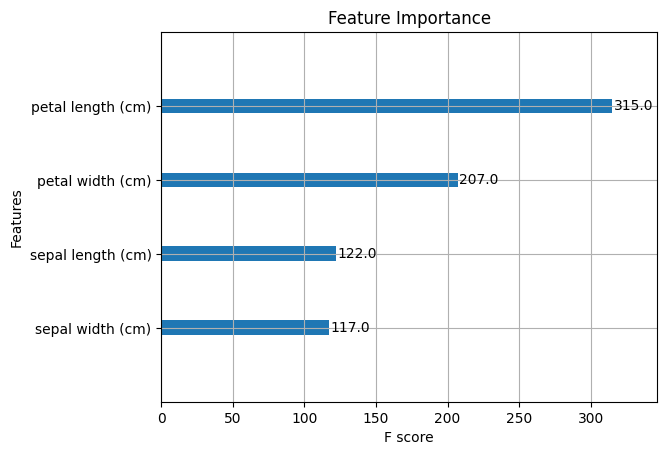

In [9]:
# Plot feature importance
xgb.plot_importance(model)
plt.title('Feature Importance')
plt.show()


/allah/freqtrade/.venv/lib/python3.11/site-packages/xgboost/core.py:160: UserWarning: [04:46:57] WARNING: /workspace/src/learner.cc:742: 
Parameters: { "n_estimators" } are not used.

  warnings.warn(smsg, UserWarning)


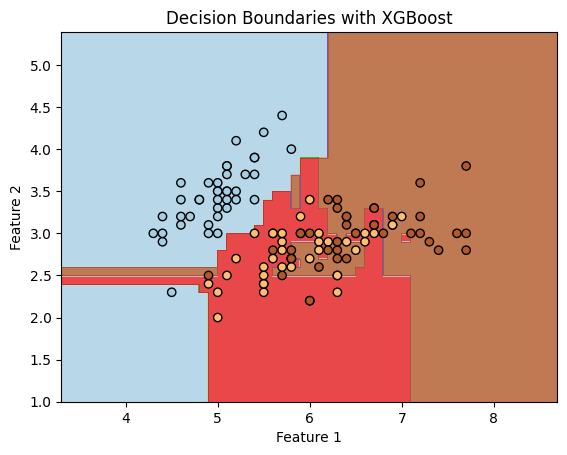

In [10]:
import numpy as np

# Use the first two features for simplicity
X_train_2d = X_train.iloc[:, :2].values
X_test_2d = X_test.iloc[:, :2].values

# Train a 2D model for visualization
dtrain_2d = xgb.DMatrix(data=X_train_2d, label=y_train)
dtest_2d = xgb.DMatrix(data=X_test_2d, label=y_test)
model_2d = xgb.train(params=params, dtrain=dtrain_2d, num_boost_round=100)

# Create a mesh grid
x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))

# Predict on the mesh grid
Z = model_2d.predict(xgb.DMatrix(np.c_[xx.ravel(), yy.ravel()]))
Z = Z.reshape(xx.shape)

# Plot decision boundaries
plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.Paired)
plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train, edgecolor='k', cmap=plt.cm.Paired)
plt.title('Decision Boundaries with XGBoost')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()


In [11]:
X_train_2d 

array([[4.6, 3.6],
       [5.7, 4.4],
       [6.7, 3.1],
       [4.8, 3.4],
       [4.4, 3.2],
       [6.3, 2.5],
       [6.4, 3.2],
       [5.2, 3.5],
       [5. , 3.6],
       [5.2, 4.1],
       [5.8, 2.7],
       [6. , 3.4],
       [6.7, 3.1],
       [5.4, 3.9],
       [5.4, 3.7],
       [5.5, 2.4],
       [6.3, 2.8],
       [6.4, 3.1],
       [6.6, 3. ],
       [7.2, 3.6],
       [5.7, 2.9],
       [7.6, 3. ],
       [5.6, 3. ],
       [5.1, 3.5],
       [7.7, 2.8],
       [5.8, 2.7],
       [5.2, 3.4],
       [5. , 3.5],
       [5.1, 3.8],
       [5. , 2. ],
       [6.3, 2.7],
       [4.8, 3.4],
       [5. , 3. ],
       [5.1, 3.3],
       [5.6, 2.7],
       [5.1, 3.4],
       [5.7, 3. ],
       [7.7, 3.8],
       [4.6, 3.2],
       [6.2, 2.9],
       [5.7, 2.5],
       [5.5, 4.2],
       [6. , 3. ],
       [5.8, 2.7],
       [6. , 2.2],
       [5.4, 3. ],
       [6.2, 3.4],
       [5.5, 2.3],
       [5.4, 3.9],
       [5. , 2.3],
       [6.4, 2.7],
       [5. , 3.3],
       [5. ,